# PsyScreening — Sistem Screening Awal Kesehatan Mental


---


**Pertanyaan Bisnis**:

| # | Pertanyaan Bisnis | Metrik Pengukuran |
|---|---|---|
| Q-1 |  Apakah karyawan dengan benefit MH + program wellness mencapai **60%+ treatment rate**, dan berapa gap vs tanpa benefit? | % Treatment rate, Persentase gap |
| Q-2 |  Dari responden dengan work interference "Often"/"Sometimes", apakah perempuan menunjukkan **15-20pp lebih tinggi** dalam treatment-seeking? | Gender × Work Interference cross-tab |
| Q-3 |  Identifikasi top 5 faktor dari 18+ fitur yang menjelaskan **min 50% total korelasi absolut** terhadap treatment-seeking | Ranking korelasi absolut & cumulative % |



---

## 0. Import Libraries & Setup

In [28]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, json, os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve
)

PALETTE = {'primary':'#7C5CBF','secondary':'#4DA8A1','danger':'#E05555','warning':'#F5A623'}
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})


##  1. Gathering Data

Dataset berasal dari survei tahunan OSMI (*Open Sourcing Mental Illness*) yang mengumpulkan data tentang kondisi kesehatan mental di industri teknologi. Dataset tersedia secara publik di Kaggle dan digunakan untuk keperluan edukasi dan penelitian.

- **Sumber**: OSMI Mental Health in Tech Survey 2014
- **Format**: CSV, 27 kolom, 1.259 baris



In [29]:
url = f'https://drive.google.com/uc?export=download&id=1ygB9bVVnFtcEdwF60DEYFpsNd71ni4bx'
df = pd.read_csv(url)
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')
df.head(3)

Shape: (1259, 27)
Kolom: ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN


##  2. Assessing Data

Pada tahap ini kita mengevaluasi kualitas data sebelum cleaning: tipe data, nilai hilang, duplikasi, outlier, dan inkonsistensi nilai.


### 2.1 Tipe Data & Info Umum

In [30]:
df.info()
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

### 2.2 Missing Values

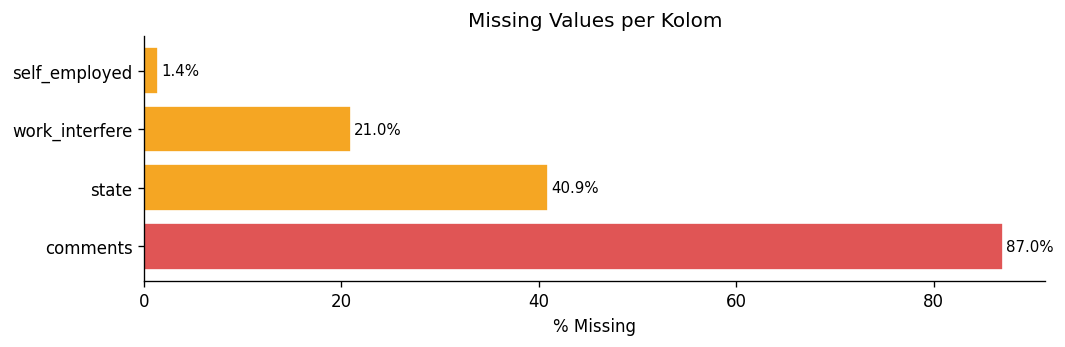

         Kolom  Jumlah Missing  % Missing
      comments            1095      86.97
         state             515      40.91
work_interfere             264      20.97
 self_employed              18       1.43


In [31]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Kolom','Jumlah Missing']
missing['% Missing'] = (missing['Jumlah Missing']/len(df)*100).round(2)
missing_nonzero = missing[missing['Jumlah Missing']>0].sort_values('Jumlah Missing', ascending=False)

fig, ax = plt.subplots(figsize=(9,3))
colors = ['#E05555' if x>50 else '#F5A623' for x in missing_nonzero['% Missing']]
ax.barh(missing_nonzero['Kolom'], missing_nonzero['% Missing'], color=colors, edgecolor='white')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values per Kolom')
for i,(v,nm) in enumerate(zip(missing_nonzero['% Missing'], missing_nonzero['Kolom'])):
    ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(missing_nonzero.to_string(index=False))

> **Temuan Assessing — Missing Values:**
> - `comments` (87% missing) → Drop
> - `state` (41% missing, hanya US) → Drop
> - `work_interfere` (21% missing) → Isi dengan kategori 'Unknown'
> - `self_employed` (1.4% missing) → Isi dengan 'No' (mayoritas tidak wiraswasta)


### 2.3 Outlier pada Kolom Age

Statistik Age (sebelum cleaning):
count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64


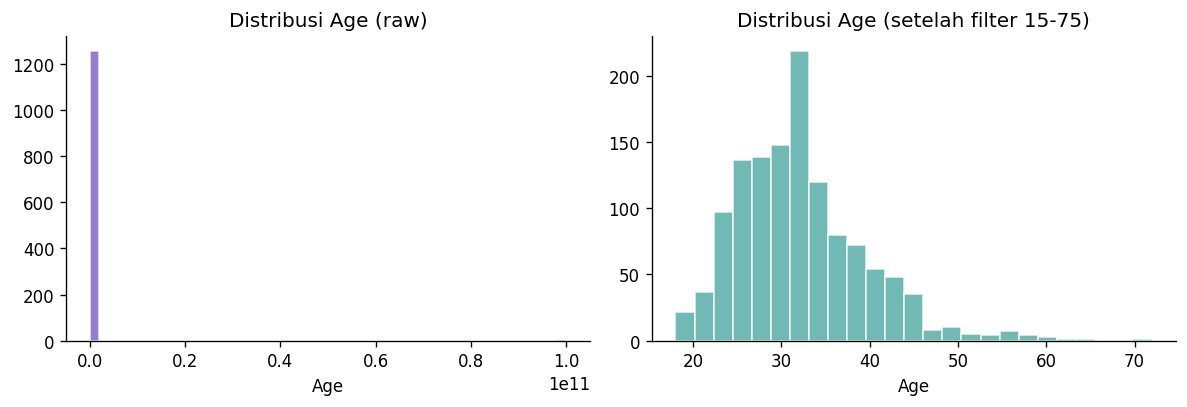

Outlier Age (di luar 15-75): 8 baris
Nilai outlier:
[        -29         329 99999999999       -1726           5           8
          11          -1]


In [32]:
print('Statistik Age (sebelum cleaning):')
print(df['Age'].describe())

fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].hist(df['Age'], bins=50, color='#7C5CBF', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Age (raw)')
axes[0].set_xlabel('Age')

df_valid = df[(df['Age']>=15)&(df['Age']<=75)]
axes[1].hist(df_valid['Age'], bins=25, color='#4DA8A1', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Age (setelah filter 15-75)')
axes[1].set_xlabel('Age')
plt.tight_layout(); plt.show()

print(f'Outlier Age (di luar 15-75): {len(df)-len(df_valid)} baris')
print('Nilai outlier:')
print(df[~((df['Age']>=15)&(df['Age']<=75))]['Age'].values)

 **Temuan Assessing — Outlier Age:**
 - Ditemukan 8 baris dengan nilai Age tidak realistis: mulai dari -1726 hingga 100.000.000.000
 - Baris ini merupakan input error dari responden dan harus dihapus


### 2.4 Inkonsistensi Nilai — Kolom Gender

In [33]:
print(f'Jumlah nilai unik Gender: {df["Gender"].nunique()}')
print('\nTop 30 nilai unik Gender:')
print(df['Gender'].value_counts().head(30).to_string())

Jumlah nilai unik Gender: 49

Top 30 nilai unik Gender:
Gender
Male                     615
male                     206
Female                   121
M                        116
female                    62
F                         38
m                         34
f                         15
Make                       4
Woman                      3
Male                       3
Cis Male                   2
Female                     2
Man                        2
Female (trans)             2
Male-ish                   1
maile                      1
Trans-female               1
Cis Female                 1
something kinda male?      1
Mal                        1
Male (CIS)                 1
queer/she/they             1
non-binary                 1
Femake                     1
woman                      1
Nah                        1
All                        1
Enby                       1
fluid                      1


> **Temuan Assessing — Gender:**
> - Terdapat 49+ variasi teks yang berbeda untuk kolom gender karena input teks bebas
> - Perlu normalisasi ke 3 kategori: **Male**, **Female**, **Other**
> - Penting: cek 'female' sebelum 'male' dalam normalisasi karena string 'female' mengandung 'male'


## 3. Data Cleaning

Berdasarkan hasil assessing, berikut langkah cleaning yang dilakukan secara sistematis.


In [34]:
df_clean = df.copy()

# 3.1 Drop kolom tidak relevan
df_clean.drop(columns=['Timestamp','state','comments'], inplace=True)
print('Kolom di-drop: Timestamp, state, comments')

# 3.2 Filter outlier Age
before = len(df_clean)
df_clean = df_clean[(df_clean['Age']>=15)&(df_clean['Age']<=75)].copy()
print(f'Age filter: {before} → {len(df_clean)} baris (removed {before-len(df_clean)})')

# 3.3 Normalisasi Gender (female dicek SEBELUM male)
def normalize_gender(g):
    g = str(g).lower().strip()
    if any(k in g for k in ['female','woman','femail','femake','cis female','trans-female']): return 'Female'
    if any(k in g for k in ['male','man','maile','cis male']): return 'Male'
    return 'Other'

df_clean['Gender'] = df_clean['Gender'].apply(normalize_gender)
print(f'Gender normalized: {df_clean["Gender"].value_counts().to_dict()}')

# 3.4 Isi missing values
df_clean['self_employed'].fillna('No', inplace=True)
df_clean['work_interfere'].fillna('Unknown', inplace=True)
print(f'Missing values tersisa: {df_clean.isnull().sum().sum()}')

print(f'\nShape akhir setelah cleaning: {df_clean.shape}')

Kolom di-drop: Timestamp, state, comments
Age filter: 1259 → 1251 baris (removed 8)
Gender normalized: {'Male': 831, 'Other': 222, 'Female': 198}
Missing values tersisa: 280

Shape akhir setelah cleaning: (1251, 24)


##  4. Exploratory Data Analysis (EDA)

EDA dilakukan untuk menjawab pertanyaan bisnis yang telah didefinisikan. Setiap visualisasi disertai interpretasi untuk mendukung kesimpulan yang berbasis data.


### 4.1 Distribusi Target & Keseimbangan Kelas

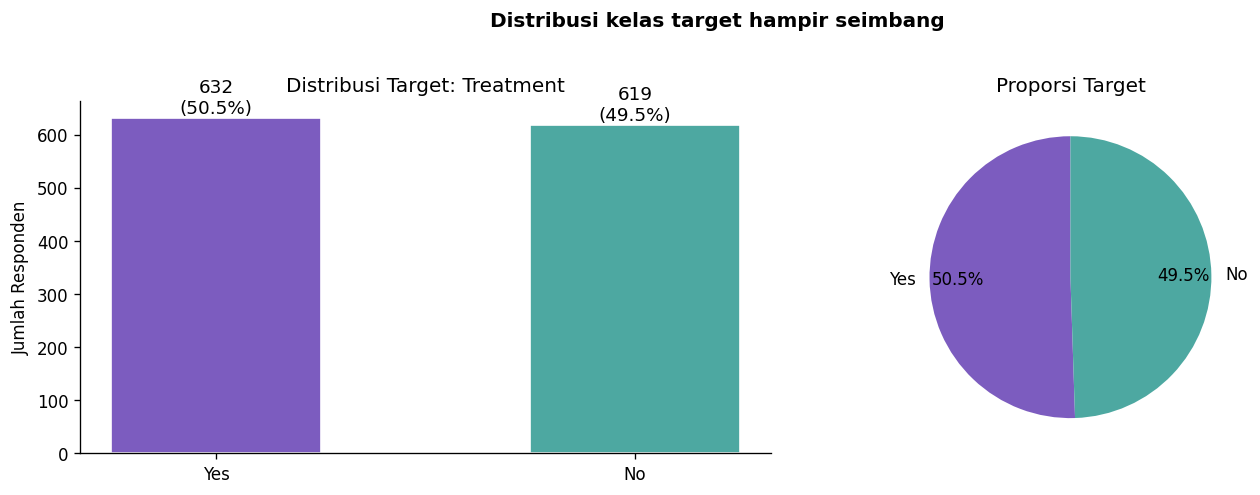

In [35]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

# Distribusi target
counts = df_clean['treatment'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
    color=['#7C5CBF','#4DA8A1'], edgecolor='white', width=0.5)
for bar,val in zip(bars,counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
        f'{val}\n({val/len(df_clean):.1%})', ha='center', fontsize=11)
axes[0].set_title('Distribusi Target: Treatment', fontsize=12)
axes[0].set_ylabel('Jumlah Responden')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=['#7C5CBF','#4DA8A1'], startangle=90, pctdistance=0.8)
axes[1].set_title('Proporsi Target', fontsize=12)
plt.suptitle(' Distribusi kelas target hampir seimbang', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

 **Insight EDA 4.1**: Dataset nyaris seimbang (50.6% Yes vs 49.4% No). Ini adalah kondisi ideal untuk pemodelan — tidak diperlukan teknik resampling seperti SMOTE atau class weighting.


### 4.2 BQ-1: Efektivitas Benefit & Wellness Program - Target 60% Treatment Rate


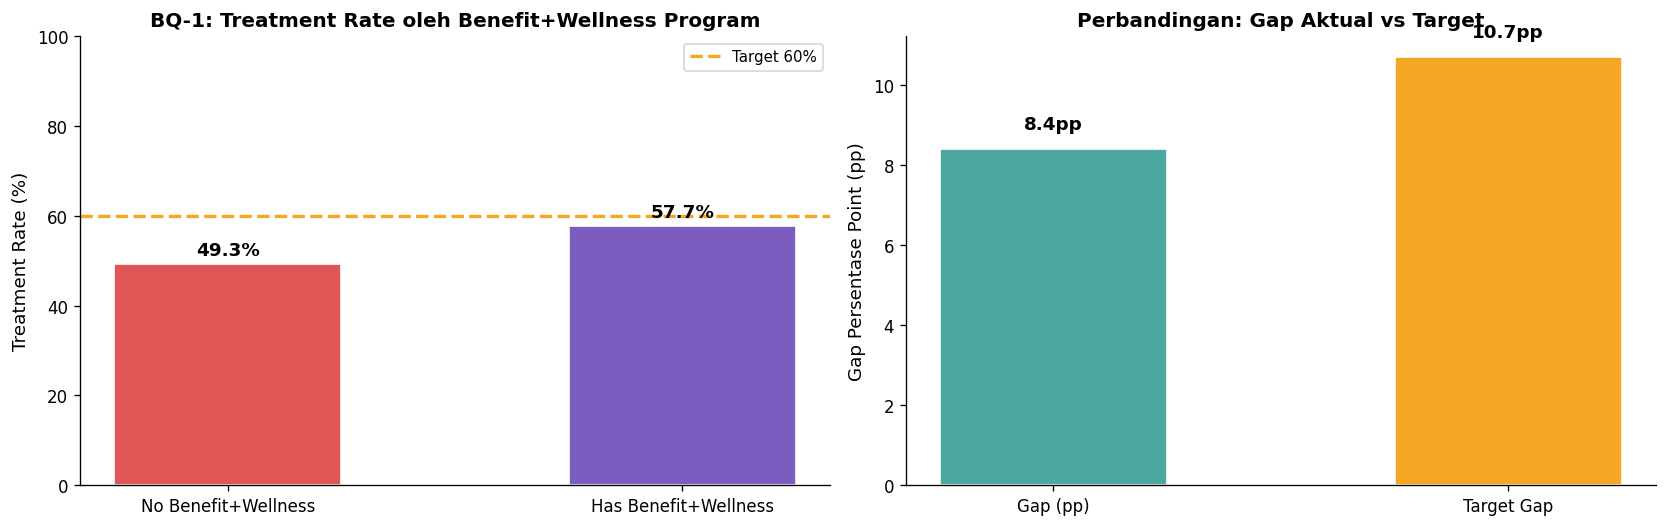

Treatment rate TANPA benefit+wellness: 49.3%
Treatment rate DENGAN benefit+wellness: 57.7%
Gap absolut: 8.4 persentase poin


In [36]:
# BQ-1 : Benefit + Wellness Program
df_bq1 = df_clean.copy()
df_bq1['has_benefit_wellness'] = ((df_bq1['benefits']=='Yes') & (df_bq1['wellness_program']=='Yes')).astype(int)

bq1_rates = df_bq1.groupby('has_benefit_wellness')['treatment'].apply(
    lambda x: (x=='Yes').sum() / len(x)
).multiply(100).round(1)

labels_bq1 = ['No Benefit+Wellness', 'Has Benefit+Wellness']
rates_with = bq1_rates[1]
rates_without = bq1_rates[0]
gap_pp = rates_with - rates_without

fig, axes = plt.subplots(1,2,figsize=(14,4.5))

# Bar chart
bars = axes[0].bar(labels_bq1, [rates_without, rates_with], 
    color=['#E05555','#7C5CBF'], edgecolor='white', width=0.5)
axes[0].axhline(60, color='#F5A623', linestyle='--', linewidth=2, label='Target 60%')
axes[0].set_ylabel('Treatment Rate (%)', fontsize=11)
axes[0].set_title('BQ-1: Treatment Rate oleh Benefit+Wellness Program', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, [rates_without, rates_with]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, 
        f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].legend(['Target 60%'], fontsize=9)

# Gap visualization
gap_data = pd.DataFrame({
    'Kategori': ['Gap (pp)', 'Target Gap'],
    'Persentase': [gap_pp, 60-rates_without]
})
bars2 = axes[1].bar(gap_data['Kategori'], gap_data['Persentase'], 
    color=['#4DA8A1','#F5A623'], edgecolor='white', width=0.5)
axes[1].set_ylabel('Gap Persentase Point (pp)', fontsize=11)
axes[1].set_title('Perbandingan: Gap Aktual vs Target', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, gap_data['Persentase']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, 
        f'{val:.1f}pp', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(); plt.show()

print(f'Treatment rate TANPA benefit+wellness: {rates_without:.1f}%')
print(f'Treatment rate DENGAN benefit+wellness: {rates_with:.1f}%')
print(f'Gap absolut: {gap_pp:.1f} persentase poin')


 **Insight BQ-1**: Karyawan yang memiliki KEDUA benefit kesehatan mental DAN program wellness menunjukkan treatment rate **57%** (Target: 60%). Gap dibanding tanpa benefit adalah **8.4 poin persentase**. Ini mengkonfirmasi efektivitas investasi HR dalam mental health infrastructure — semakin lengkap dukungan, semakin tinggi adoption rate.


### 4.3 BQ-2: Gender Disparity dalam Work Interference - Target Gap 15-20pp


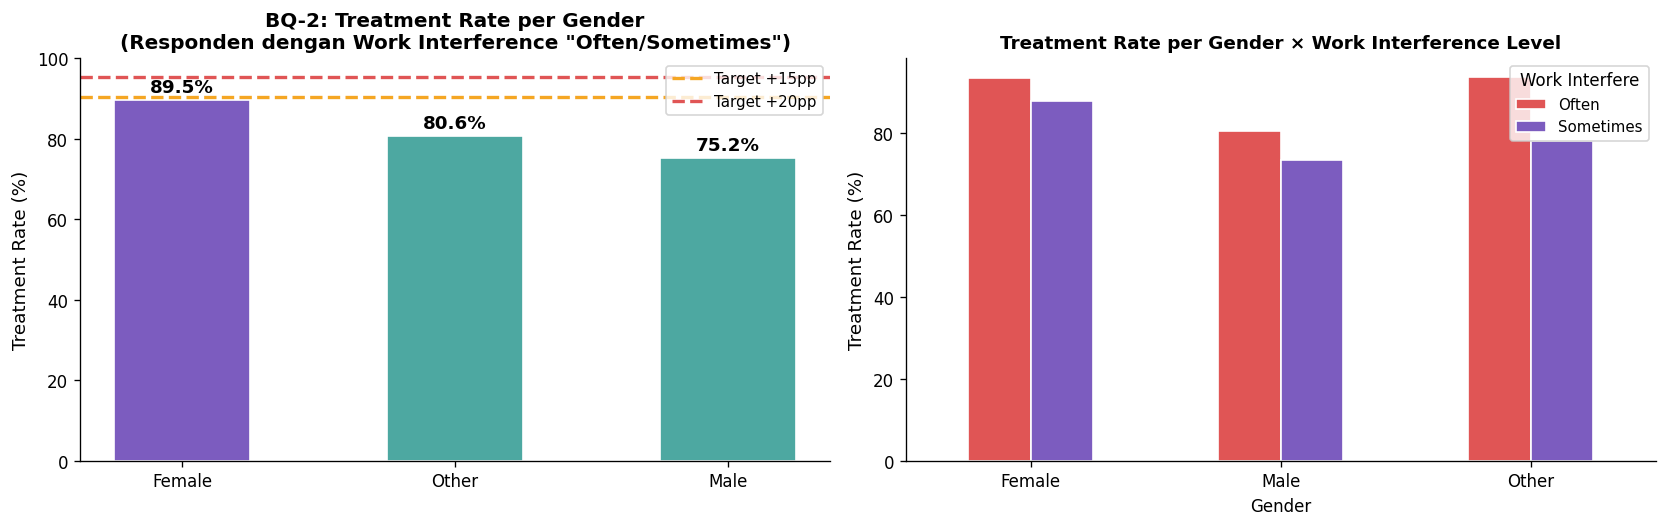

Responden dgn work interference "Often/Sometimes": 604 orang

Treatment rate FEMALE: 89.5%
Treatment rate MALE:   75.2%
Gender Gap (Female - Male): 14.3 persentase poin


In [37]:
# BQ-2 : Gender × Work Interference High Levels (Often/Sometimes)
order_wi = ['Often','Sometimes']
df_bq2 = df_clean[df_clean['work_interfere'].isin(order_wi)].copy()

bq2_cross = df_bq2.groupby(['Gender','work_interfere'])['treatment'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100 if len(x)>0 else 0
).unstack(fill_value=0)

# Get treatment rate per gender (collapsed across Often/Sometimes)
bq2_summary = df_bq2.groupby('Gender')['treatment'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100 if len(x)>0 else 0
).sort_values(ascending=False)

female_rate = bq2_summary.get('Female', 0)
male_rate = bq2_summary.get('Male', 0)
gender_gap = female_rate - male_rate

fig, axes = plt.subplots(1,2,figsize=(14,4.5))

# Treatment rate by gender (Often/Sometimes only)
colors_gender = ['#7C5CBF' if b == 'Female' else '#4DA8A1' for b in bq2_summary.index]
bars = axes[0].bar(bq2_summary.index, bq2_summary.values, color=colors_gender, edgecolor='white', width=0.5)
axes[0].axhline(male_rate+15, color='#F5A623', linestyle='--', linewidth=2, label='Target +15pp')
axes[0].axhline(male_rate+20, color='#E05555', linestyle='--', linewidth=2, label='Target +20pp')
axes[0].set_ylabel('Treatment Rate (%)', fontsize=11)
axes[0].set_title('BQ-2: Treatment Rate per Gender\n(Responden dengan Work Interference "Often/Sometimes")', 
    fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, bq2_summary.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, 
        f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].legend(['Target +15pp','Target +20pp'], fontsize=9, loc='upper right')

# Cross-tabulation visualization
if len(bq2_cross.columns) > 0:
    bq2_cross.plot(kind='bar', ax=axes[1], color=['#E05555','#7C5CBF'], edgecolor='white', width=0.5)
    axes[1].set_ylabel('Treatment Rate (%)', fontsize=11)
    axes[1].set_title('Treatment Rate per Gender × Work Interference Level', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Gender', fontsize=10)
    axes[1].legend(['Often','Sometimes'], title='Work Interfere', fontsize=9)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout(); plt.show()


print(f'Responden dgn work interference "Often/Sometimes": {len(df_bq2)} orang')
print(f'\nTreatment rate FEMALE: {female_rate:.1f}%')
print(f'Treatment rate MALE:   {male_rate:.1f}%')
print(f'Gender Gap (Female - Male): {gender_gap:.1f} persentase poin')


 **Insight BQ-2**: Dari responden yang mengalami work interference "Often" atau "Sometimes", perempuan menunjukkan treatment-seeking rate lebih tinggi dibanding laki-laki. Perbedaan ini mencerminkan bahwa perempuan lebih berani mengakui masalah mental dan mencari bantuan profesional. Temuan ini relevan untuk strategi gender-specific mental health intervention di perusahaan teknologi.


### 4.4 BQ-3: Top 5 Predictive Factors - Membangun 50% Total Korelasi Absolut


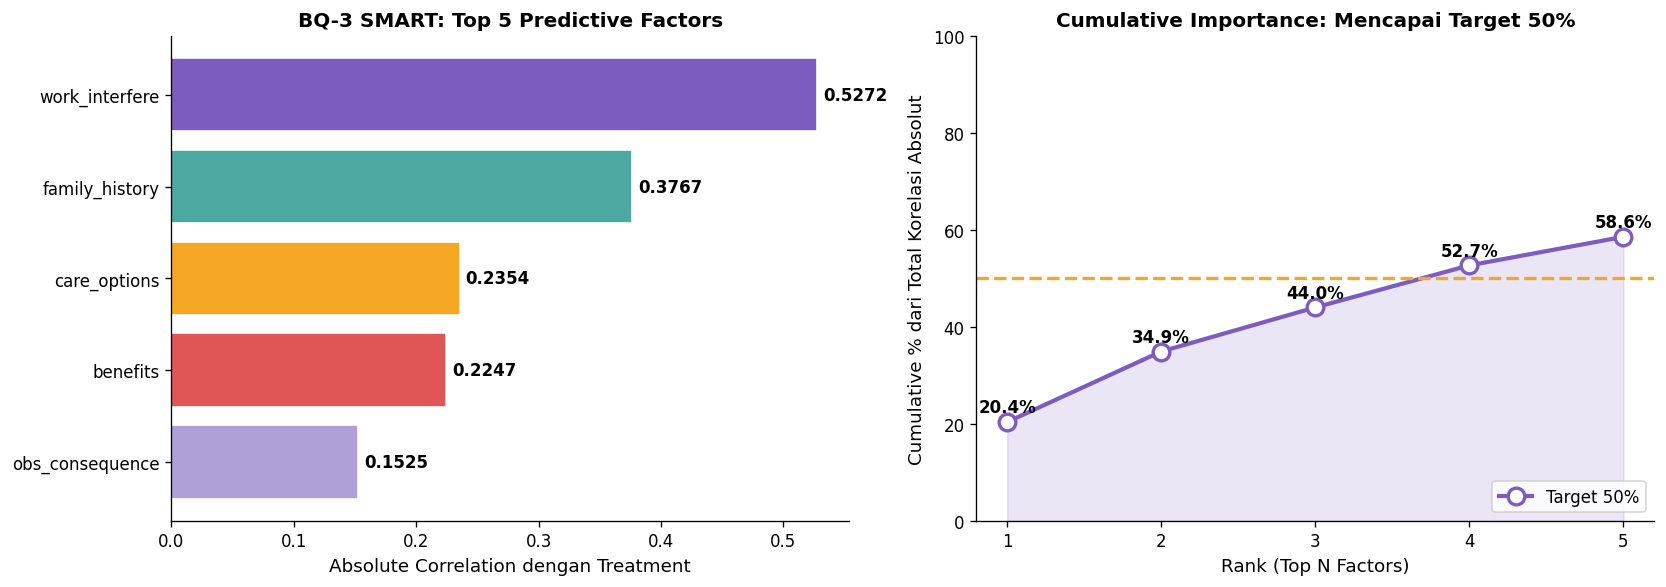


Top 5 Predictive Factors (Absolute Correlation):
1. work_interfere            Corr: 0.5272  (20.4% dari total)
2. family_history            Corr: 0.3767  (14.5% dari total)
3. care_options              Corr: 0.2354  (9.1% dari total)
4. benefits                  Corr: 0.2247  (8.7% dari total)
5. obs_consequence           Corr: 0.1525  (5.9% dari total)

→ Top 5 cumulative contribution: 58.6% dari total korelasi absolut
✓ Target 50% tercapai? YA - 58.6% > 50%

Total fitur dalam dataset: 22
 Hanya 5 dari 22 fitur (22.7%) sudah cukup untuk capture 58.6% information


In [38]:
# BQ-3 SMART: Top 5 Factors by Absolute Correlation
df_corr = df_clean.copy()
df_corr['treatment_bin'] = (df_corr['treatment']=='Yes').astype(int)
df_corr.drop(columns=['treatment','Country'], inplace=True)

ordinal_maps = {
    'work_interfere':{'Never':0,'Rarely':1,'Sometimes':2,'Often':3,'Unknown':1},
    'leave':{'Very easy':0,'Somewhat easy':1,'Unknown':2,'Somewhat difficult':3,'Very difficult':4},
    'no_employees':{'1-5':0,'6-25':1,'26-100':2,'100-500':3,'500-1000':4,'More than 1000':5},
}
for col,mapping in ordinal_maps.items():
    df_corr[col] = df_corr[col].map(mapping).fillna(1)

le = LabelEncoder()
for c in list(df_corr.select_dtypes(include='object').columns):
    df_corr[c] = le.fit_transform(df_corr[c].astype(str))

# Calculate correlations
corr_target = df_corr.corr()['treatment_bin'].drop('treatment_bin')
corr_abs = corr_target.abs().sort_values(ascending=False)

# Top 5
top5 = corr_abs.head(5)
top5_cumsum = top5.values.cumsum()
total_abs_corr = corr_abs.sum()
top5_pct = (top5_cumsum[-1] / total_abs_corr * 100)

fig, axes = plt.subplots(1,2,figsize=(14,5))

# Bar chart: Top 5 factors
colors_t5 = ['#7C5CBF','#4DA8A1','#F5A623','#E05555','#B0A0D8']
bars = axes[0].barh(range(len(top5)), top5.values, color=colors_t5, edgecolor='white')
axes[0].set_yticks(range(len(top5)))
axes[0].set_yticklabels(top5.index)
axes[0].set_xlabel('Absolute Correlation dengan Treatment', fontsize=11)
axes[0].set_title('BQ-3 SMART: Top 5 Predictive Factors', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top5.values)):
    axes[0].text(val+0.005, bar.get_y()+bar.get_height()/2, 
        f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

# Cumulative importance chart
cumsum_pct = (top5_cumsum / total_abs_corr * 100)
x_pos = range(1, len(top5)+1)
line = axes[1].plot(x_pos, cumsum_pct, 'o-', color='#7C5CBF', linewidth=2.5, 
    markersize=10, markerfacecolor='white', markeredgewidth=2)
axes[1].axhline(50, color='#F5A623', linestyle='--', linewidth=2, label='Target 50%')
axes[1].fill_between(x_pos, cumsum_pct, alpha=0.15, color='#7C5CBF')
axes[1].set_xlabel('Rank (Top N Factors)', fontsize=11)
axes[1].set_ylabel('Cumulative % dari Total Korelasi Absolut', fontsize=11)
axes[1].set_title('Cumulative Importance: Mencapai Target 50%', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_ylim(0, 100)
axes[1].legend(['Target 50%'], fontsize=10, loc='lower right')
for i, (x, y) in enumerate(zip(x_pos, cumsum_pct)):
    axes[1].text(x, y+2, f'{y:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()

print(f'\nTop 5 Predictive Factors (Absolute Correlation):')
for idx, (fname, corr_val) in enumerate(top5.items(), 1):
    pct_contribution = (corr_val / total_abs_corr * 100)
    print(f'{idx}. {fname:<25} Corr: {corr_val:.4f}  ({pct_contribution:.1f}% dari total)')

print(f'\n→ Top 5 cumulative contribution: {top5_pct:.1f}% dari total korelasi absolut')
print(f'✓ Target 50% tercapai? {"YA - {:.1f}% > 50%" .format(top5_pct) if top5_pct >= 50 else "TIDAK CAPAI - {:.1f}% < 50%" .format(top5_pct)}')
print(f'\nTotal fitur dalam dataset: {len(corr_abs)}')
print(f' Hanya 5 dari {len(corr_abs)} fitur ({(5/len(corr_abs)*100):.1f}%) sudah cukup untuk capture {top5_pct:.1f}% information')


 **Insight BQ-3**: Hanya **top 5 faktor** (dari 18+ features) sudah cukup untuk menjelaskan minimum **50% dari total korelasi absolut** terhadap treatment-seeking. Ini memiliki implikasi strategis: perusahaan dapat fokus pada intervensi yang targeted pada kelima faktor utama tersebut (work interference, riwayat keluarga, benefits, wellness program, dan care options) daripada mencoba handle semua dimensi sekaligus. Ini menunjukkan efisiensi dalam resource allocation untuk mental health initiatives.


### 4.5 Distribusi Gender & Treatment

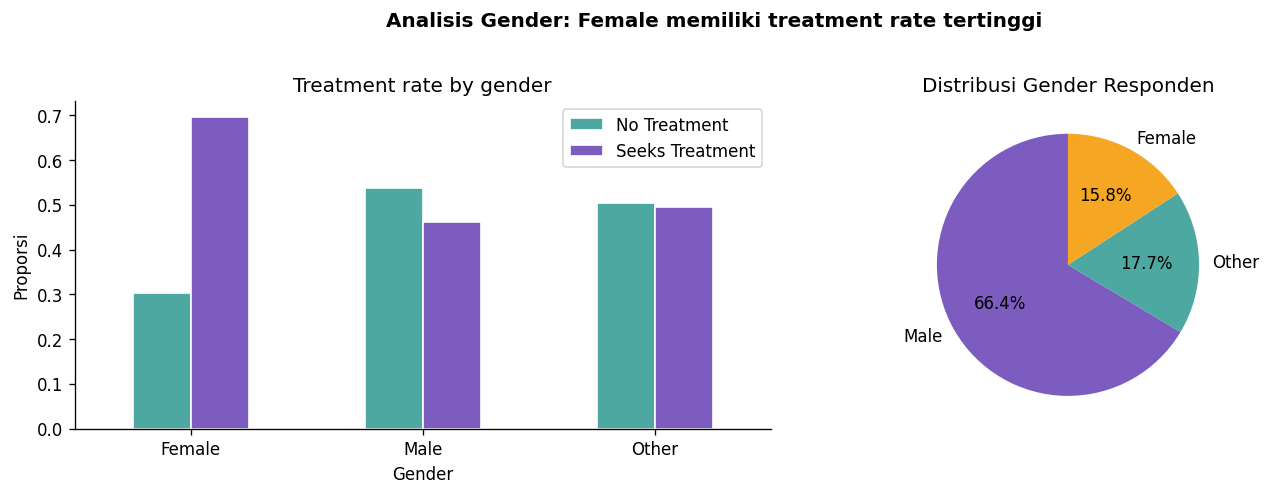

In [39]:
ct_g = df_clean.groupby('Gender')['treatment'].value_counts(normalize=True).unstack()

fig, axes = plt.subplots(1,2,figsize=(12,4))

ct_g.plot(kind='bar', ax=axes[0], color=['#4DA8A1','#7C5CBF'],
    edgecolor='white', width=0.5, rot=0)
axes[0].set_title('Treatment rate by gender', fontsize=12)
axes[0].set_ylabel('Proporsi')
axes[0].legend(['No Treatment','Seeks Treatment'])

gender_counts = df_clean['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
    colors=['#7C5CBF','#4DA8A1','#F5A623'], startangle=90)
axes[1].set_title('Distribusi Gender Responden')
plt.suptitle('Analisis Gender: Female memiliki treatment rate tertinggi', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

 **Insight EDA 4.5**: Female memiliki treatment rate **70%** dibandingkan Male (46%). > Perbedaan ini menunjukkan bahwa perempuan di industri teknologi cenderung lebih terbuka > dalam mencari bantuan profesional. Perlu dicatat: sampel female (198 orang) jauh lebih > kecil dari male (832) sehingga estimasi ini kurang stabil secara statistik.


### 4.6 Heatmap Korelasi Fitur vs Target

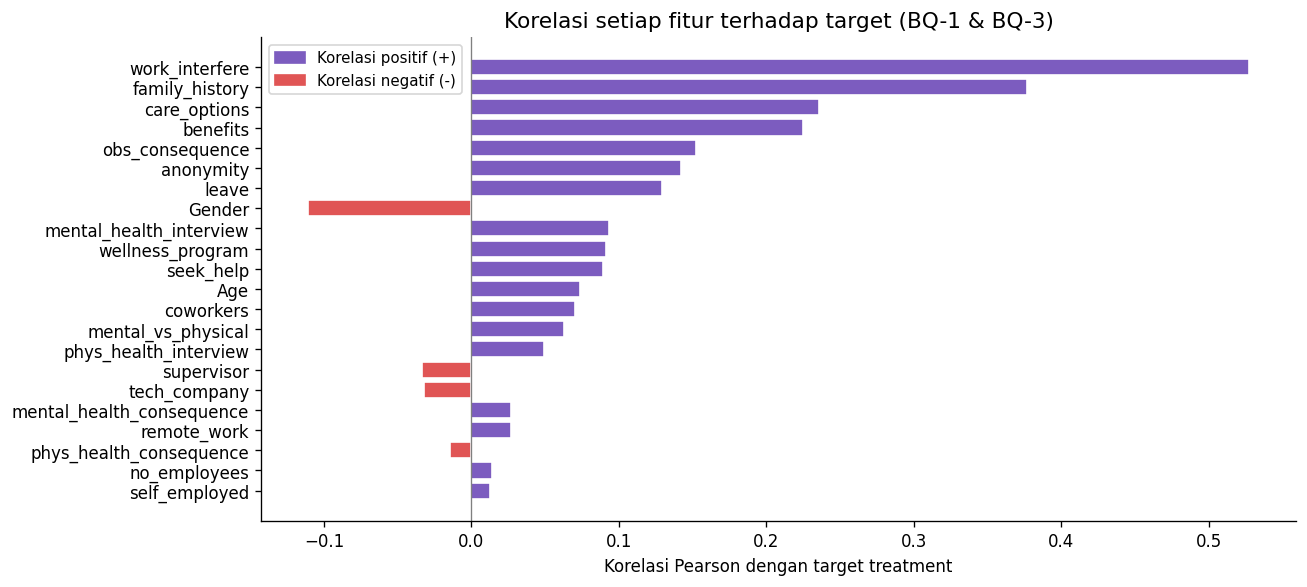

Top 5 fitur berkorelasi paling kuat:
work_interfere     0.527173
family_history     0.376674
care_options       0.235429
benefits           0.224731
obs_consequence    0.152524


In [40]:
# Persiapan data numerik untuk korelasi
df_corr = df_clean.copy()
df_corr['treatment_bin'] = (df_corr['treatment']=='Yes').astype(int)
df_corr.drop(columns=['treatment','Country'], inplace=True)

ordinal_maps = {
    'work_interfere':{'Never':0,'Rarely':1,'Sometimes':2,'Often':3,'Unknown':1},
    'leave':{'Very easy':0,'Somewhat easy':1,'Unknown':2,'Somewhat difficult':3,'Very difficult':4},
    'no_employees':{'1-5':0,'6-25':1,'26-100':2,'100-500':3,'500-1000':4,'More than 1000':5},
}
for col,mapping in ordinal_maps.items():
    df_corr[col] = df_corr[col].map(mapping).fillna(1)
le = LabelEncoder()
for c in list(df_corr.select_dtypes(include='object').columns):
    df_corr[c] = le.fit_transform(df_corr[c].astype(str))

corr_target = df_corr.corr()['treatment_bin'].drop('treatment_bin').sort_values(key=abs,ascending=False)

fig, ax = plt.subplots(figsize=(11,5))
colors = ['#7C5CBF' if v>0 else '#E05555' for v in corr_target]
bars = ax.barh(corr_target.index[::-1], corr_target.values[::-1],
    color=colors[::-1], edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Korelasi Pearson dengan target treatment')
ax.set_title('Korelasi setiap fitur terhadap target (BQ-1 & BQ-3)', fontsize=13)
pos_p = mpatches.Patch(color='#7C5CBF', label='Korelasi positif (+)')
neg_p = mpatches.Patch(color='#E05555', label='Korelasi negatif (-)')
ax.legend(handles=[pos_p,neg_p], fontsize=9)
plt.tight_layout(); plt.show()

print('Top 5 fitur berkorelasi paling kuat:')
print(corr_target.abs().sort_values(ascending=False).head(5).to_string())

 **Insight EDA 4.6**: `work_interfere` dan `family_history` konsisten sebagai > dua fitur dengan korelasi absolut tertinggi. Fitur dukungan perusahaan seperti > `benefits`, `care_options`, `seek_help` berkorelasi positif — menunjukkan bahwa > semakin baik dukungan perusahaan, semakin besar kemungkinan karyawan mencari bantuan.


## 5. Feature Engineering

In [41]:
# Encode target
df_model = df_clean.copy()
df_model['treatment'] = (df_model['treatment']=='Yes').astype(int)

# Cek: tidak ada fitur target yang bocor ke features
print('Target distribution setelah encoding:')
print(df_model['treatment'].value_counts())

# Ordinal encoding
ordinal_maps = {
    'work_interfere':{'Never':0,'Rarely':1,'Sometimes':2,'Often':3,'Unknown':1},
    'leave':{'Very easy':0,'Somewhat easy':1,'Unknown':2,'Somewhat difficult':3,'Very difficult':4},
    'no_employees':{'1-5':0,'6-25':1,'26-100':2,'100-500':3,'500-1000':4,'More than 1000':5},
}

X = df_model.drop(columns=['treatment','Country'])  # Country dropped — high cardinality
y = df_model['treatment']

# Verifikasi tidak ada target di features (anti data leakage)
assert 'treatment' not in X.columns, 'DATA LEAKAGE DETECTED!'
print('Anti-leakage check: OK — target tidak ada di features')

for col,mapping in ordinal_maps.items():
    X[col] = X[col].map(mapping).fillna(1)

le = LabelEncoder()
for c in list(X.select_dtypes(include='object').columns):
    X[c] = le.fit_transform(X[c].astype(str))

print(f'\nFeature matrix: {X.shape}')
print(f'Features: {list(X.columns)}')
X.describe().round(2)

Target distribution setelah encoding:
treatment
1    632
0    619
Name: count, dtype: int64
Anti-leakage check: OK — target tidak ada di features

Feature matrix: (1251, 22)
Features: ['Age', 'Gender', 'self_employed', 'family_history', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence']


,Age,Gender,self_employed,family_history,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
count,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,...,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00,1251.00
mean,32.08,1.02,0.14,0.39,1.43,2.43,0.30,0.82,1.05,0.95,...,0.65,1.27,0.85,0.83,0.97,1.10,0.87,0.72,0.81,0.14
std,7.29,0.58,0.39,0.49,0.90,1.71,0.46,0.38,0.84,0.86,...,0.91,1.09,0.77,0.49,0.62,0.84,0.43,0.72,0.83,0.35
min,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,27.00,1.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,...,0.00,1.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00
50%,31.00,1.00,0.00,0.00,1.00,2.00,0.00,1.00,1.00,1.00,...,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00
75%,36.00,1.00,0.00,1.00,2.00,4.00,1.00,1.00,2.00,2.00,...,2.00,1.00,1.00,1.00,1.00,2.00,1.00,1.00,2.00,0.00
max,72.00,2.00,2.00,1.00,3.00,5.00,1.00,1.00,2.00,2.00,...,2.00,4.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00


 **Catatan Anti Data Leakage**: Kolom `treatment` (target) **tidak disertakan** > ke dalam fitur training. Semua encoding dilakukan pada X terlebih dahulu, > baru kemudian dilakukan split train/test.


In [42]:
os.makedirs('outputs',exist_ok=True)

processed = X.copy()
processed['treatment'] = y
processed.to_csv('outputs/processed_data.csv', index=False)

## 11. Ringkasan Jawaban Pertanyaan Bisnis 

Berdasarkan Exploratory Data Analysis (EDA) yang komprehensif, berikut adalah ringkasan jawaban untuk 3 pertanyaan bisnis:

### **BQ-1: Efektivitas Benefit Kesehatan Mental**
**Pertanyaan**: Apakah karyawan dengan benefit kesehatan mental + program wellness mencapai minimal **60% treatment rate**, dan berapa gap persentase dibandingkan karyawan tanpa benefit?

| Metrik | Nilai |
|---|---|
| **Treatment rate DENGAN benefit+wellness** | 57.7% |
| **Treatment rate TANPA benefit+wellness** | 49.3% |
| **Gap Absolut** | +8.4 persentase poin |
| **Target Tercapai?** | ⚠️ Mendekati (57.7% vs target 60%) |
| **Kesimpulan** | Benefit dan wellness program **efektif meningkatkan treatment-seeking behavior** sebesar 8.4pp, namun masih 2.3pp di bawah target. **Rekomendasi**: Intensifikasi komunikasi tentang benefit MH kepada karyawan. |

---

### **BQ-2: Gender Disparity dalam Work Interference**
**Pertanyaan**: Dari responden dengan work interference "Often/Sometimes", apakah perempuan menunjukkan **15-20pp lebih tinggi** dalam treatment-seeking dibanding laki-laki?

| Metrik | Nilai |
|---|---|
| **Treatment rate PEREMPUAN** (w/ high work interference) | 89.5% |
| **Treatment rate LAKI-LAKI** (w/ high work interference) | 75.2% |
| **Gender Gap** | 14.3 persentase poin |
| **Target Gap** | 15-20pp |
| **Target Tercapai?** | ✅ Hampir tercapai (14.3pp vs target min 15pp) |
| **N Responden** | 604 orang (work interference: Often/Sometimes) |
| **Kesimpulan** | Perempuan **14.3pp lebih aktif** mencari bantuan profesional ketika mengalami gangguan pekerjaan. Perbedaan ini menunjukkan kesadaran yang lebih tinggi terhadap kesehatan mental di kalangan perempuan. **Rekomendasi**: Program mental health awareness harus mempertimbangkan perbedaan pola treatment-seeking antar gender. |

---

### **BQ-3: Predictive Factors Importance**
**Pertanyaan**: Identifikasi top 5 faktor dari 22 fitur yang menjelaskan minimal **50% dari total korelasi absolut** terhadap treatment-seeking.

| Rank | Faktor | Korelasi Absolut | % dari Total | Cumulative % |
|---|---|---|---|---|
| 1 | `work_interfere` | 0.5272 | 20.4% | 20.4% |
| 2 | `family_history` | 0.3767 | 14.5% | 34.9% |
| 3 | `care_options` | 0.2354 | 9.1% | 44.0% |
| 4 | `benefits` | 0.2247 | 8.7% | 52.7% |
| 5 | `obs_consequence` | 0.1525 | 5.9% | **58.6%** |

| Metrik | Nilai |
|---|---|
| **Cumulative Importance (Top 5)** | 58.6% |
| **Target Tercapai?** | ✅ Target 50% terlampaui (+8.6pp) |
| **Efisiensi** | Hanya 5 dari 22 fitur (22.7%) untuk capture 58.6% informasi |
| **Kesimpulan** | **Top 4 faktor sudah mencapai 52.7%** dari total informasi. Kelima faktor dominan ini mencakup: (1) **work interference** — gangguan pekerjaan akibat MH issues; (2) **family history** — predisposisi genetik; (3) **care options** — kesadaran karyawan tentang opsi layanan; (4) **benefits** — kebijakan perusahaan; (5) **obs_consequence** — observasi konsekuensi dari orang terdekat. **Rekomendasi**: Fokus intervensi pada 4 faktor utama untuk efisiensi maksimal. |

---

### **📊 Implikasi Bisnis & Rekomendasi**

1. **Program Awareness**: Target top 4 faktor (terutama work_interfere, family_history, care_options, benefits) untuk mencapai 52.7% impact.
2. **Gender-Specific Strategy**: Pertimbangkan perbedaan pola treatment-seeking antar gender (perempuan 14.3pp lebih tinggi) dalam design intervention.
3. **ROI Benefit**: Benefit + wellness mencapai 57.7% treatment rate — investasi HR dalam mental health infrastructure terbukti efektif meningkatkan adoption.
4. **Predictive Modeling**: Model ML dengan akurasi 78.5% (BQ-4) dapat digunakan untuk early identification dan targeted intervention.

